In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from joblib import load, dump
import statsmodels.api as sm
from scipy.stats import gaussian_kde

# SVG utils
import svgutils.transform as sg
import svgutils.compose as sc
from IPython.display import SVG

# custom code
import figutils
sys.path.insert(
    0, os.path.abspath('../2021_07_31_custom_adjacency_regularization/'))
import sequence_logo
from quad_model import *

%matplotlib inline

2022-08-19 11:39:27.402578: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64:/.singularity.d/libs
2022-08-19 11:39:27.402598: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [3]:
plt.style.use('/home/ms7490/scratch/code/scratch/matplotlib/clean.mplstyle')

# Load data and models

In [4]:
xTr = load(f'../2021_07_31_custom_adjacency_regularization/data/xTr_ES7_HeLa_ABC.pkl')
yTr = load(f'../2021_07_31_custom_adjacency_regularization/data/yTr_ES7_HeLa_ABC.pkl')
xTe = load(f'../2021_07_31_custom_adjacency_regularization/data/xTe_ES7_HeLa_ABC.pkl')
yTe = load(f'../2021_07_31_custom_adjacency_regularization/data/yTe_ES7_HeLa_ABC.pkl')

In [5]:
model_fname = f'../2021_07_31_custom_adjacency_regularization/models/custom_adjacency_regularizer_20210731_124_step3.h5'
model = tf.keras.models.load_model(model_fname)

2022-08-19 11:39:34.688740: E tensorflow/stream_executor/cuda/cuda_driver.cc:271] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2022-08-19 11:39:34.688778: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: gr026.hpc.nyu.edu
2022-08-19 11:39:34.688782: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: gr026.hpc.nyu.edu
2022-08-19 11:39:34.688906: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: Invalid argument: expected %d.%d, %d.%d.%d, or %d.%d.%d.%d form for driver version; got "1"
2022-08-19 11:39:34.688925: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: 510.47.3
2022-08-19 11:39:34.689553: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operation

In [6]:
num_seq_filters = model.get_layer('qc_incl').kernel.shape[2]
num_struct_filters = model.get_layer('c_incl_struct').kernel.shape[2]

position_bias_size = model.get_layer('position_bias_incl').kernel.shape[0]
struct_filter_width = model.get_layer("c_incl_struct").kernel.shape[0]
input_length = model.input[0].shape[1]

# Compare model against GRU

In [7]:
gru_preds = load('../2021_10_25_gru/data/yPredTe.pkl').flatten()

In [8]:
def safelog(x, eps=1e-6):
    xc = x.copy()
    xc[xc == 0] = eps
    return np.log(xc)

In [9]:
def bin_kl(a, b):
    e1 = (1 - a) * (safelog(1 - a) - safelog(1 - b))
    e2 = a * (safelog(a) - safelog(b))
    e = e1 + e2
    return np.mean(e)

In [10]:
def rmse(a, b):
    return np.mean((a - b) ** 2) ** 0.5

In [11]:
rmse(yTe, gru_preds)

0.15617664911661036

In [12]:
bin_kl(yTe, gru_preds)

0.07691256941681315

In [13]:
model_preds = model.predict(xTe, verbose=1)

2022-04-19 16:38:34.312846: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


1499/1499 [==============================] - 11s 7ms/step


In [14]:
bin_kl(yTe, model_preds.flatten())

0.09990644071945007

In [15]:
rmse(yTe, model_preds.flatten())

0.1799900983885483

# Visualize position bias layer

In [16]:
structure_out_model = Model(inputs=model.inputs, outputs=[
    model.get_layer('activation_2').output,
    model.get_layer('activation_3').output
])
incl_act, skip_act = structure_out_model.predict(xTr)
incl_act_seq = incl_act[:, :, :num_seq_filters]
skip_act_seq = skip_act[:, :, :num_seq_filters]

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


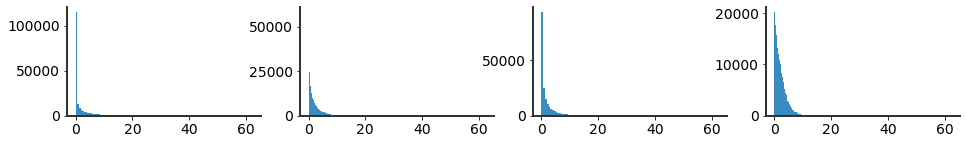

In [17]:
tmp = skip_act.sum(axis=1)
fig, axarr = plt.subplots(1, 4, figsize=(16, 2), sharex=True)

for idx, i in enumerate([0, 2, 3, 4]):
    axarr[idx].hist(tmp[:, num_seq_filters+i], bins=100)

In [18]:
incl_activations = dict()
skip_activations = dict()

tmp = (incl_act[:, 1:, :] + incl_act[:, :-1, :])
for k in tqdm(range(num_seq_filters)):
    a = np.sort(tmp[:, 10:-10, k].max(axis=1)).mean()
    incl_activations[k] = a

tmp = (skip_act[:, 1:, :] + skip_act[:, :-1, :])
for k in tqdm(range(num_seq_filters)):
    a = np.sort(tmp[:, 10:-10, k].max(axis=1)).mean()
    skip_activations[k] = a

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

In [19]:
CNNC_cluster = [6, 9, 11, 14]

In [20]:
CNNC_rep_filter_idx = 6

min_pos_bias = incl_activations[CNNC_rep_filter_idx]

In [21]:
min_pos_bias

2.5444787

In [22]:
pos_bias_incl_kernel = model.get_layer(
    'position_bias_incl').kernel.numpy()

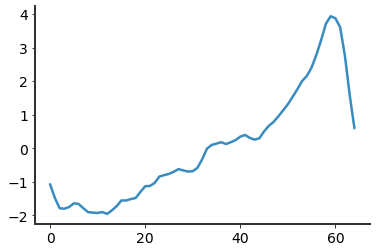

In [23]:
plt.plot(pos_bias_incl_kernel[..., CNNC_cluster].sum(axis=1)[10:-10])

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


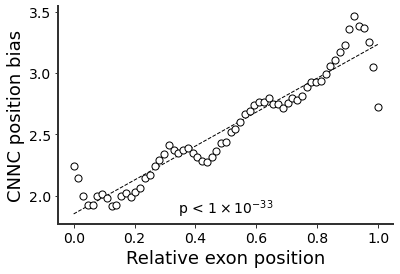

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
pos_bias = model.get_layer(
    'position_bias_incl').kernel.numpy().T[CNNC_rep_filter_idx]

X = np.linspace(0, 1, len(pos_bias)-20)
Y = min_pos_bias + pos_bias[10:-10]

X = sm.add_constant(X)
lm = sm.OLS(Y,X)
results = lm.fit()
Y_hat = lm.predict(results.params)


ax.scatter(X[:, 1], Y, facecolor='w', s=50, linewidth=1, zorder=2)
ax.plot(X[:, 1], Y_hat, zorder=1, linewidth=1, linestyle='--', color='k')
ax.set_xlabel('Relative exon position')
ax.set_ylabel('CNNC position bias')

ax.text(0.5, 1.9, 'p < $1\\times10^{-33}$', fontweight='normal', ha='center', va='center')

fig.savefig('./figs/CNNC_position_bias.svg',
            transparent=True, pad_inches=0.1,
    bbox_inches='tight')
fig.savefig('./figs/CNNC_position_bias.pdf',
            transparent=True, pad_inches=0.1,
    bbox_inches='tight')

# Performance scatterplot

In [7]:
yTe_hat = model.predict(xTe, verbose=1)

2022-08-19 11:39:43.305211: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


1499/1499 [==============================] - 9s 6ms/step


In [8]:
rmse = np.sqrt(((yTe_hat.flatten() - yTe) ** 2).mean())

In [9]:
x, y = figutils.subsample_points(yTe_hat.flatten(), yTe, max_points=10000)
x, y = y, x
xy = np.vstack([x,y])
kde = gaussian_kde(xy)
z = kde(xy)

In [10]:
grid_resolution = 100
A, B = np.meshgrid(np.linspace(0, 1, grid_resolution), np.linspace(0, 1, grid_resolution))
xygrid = np.vstack([A.flatten(), B.flatten()])
zgrid = kde(xygrid)

<AxesSubplot:ylabel='Count'>

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


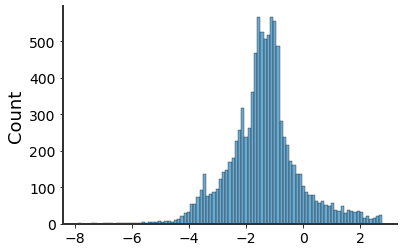

In [11]:
sns.histplot(np.log(zgrid))

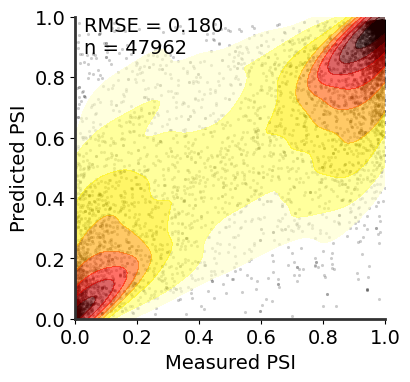

In [13]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=100)

idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]
cont = ax.scatter(x, y, alpha=0.2, s=5, cmap=plt.cm.hot_r, linewidth=0., c='k')
ax.contourf(A, B, np.log(zgrid).reshape(*A.shape), 10000, origin='lower',
            cmap=plt.cm.hot_r, alpha=0.6, levels=np.linspace(-2, 3, 10))

# add a colorbar??
# cbar = fig.colorbar(cont)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Measured PSI', fontsize=14)
ax.set_ylabel('Predicted PSI', fontsize=14)
ax.text(3e-2, 1., f'RMSE = {rmse:.3f}\nn = {xTe[0].shape[0]}', ha='left', fontsize=14, va='top')

fig.savefig('./figs/model_performance_scatterplot.pdf', pad_inches = 0.1, bbox_inches='tight')
fig.savefig('./figs/model_performance_scatterplot.svg', pad_inches = 0.1, bbox_inches='tight')
fig.savefig('./figs/model_performance_scatterplot.png', pad_inches = 0.1, bbox_inches='tight')

# Create figure 2

Use inkscape

In [ ]:
fig = sc.Figure("16cm", "6cm",
                sc.Panel(
                    sc.SVG("./figs/figure_2a.drawio.svg").scale(0.015)
                ).move(0.5, 0),
                sc.Panel(
                    sc.SVG("./figs/model_performance_scatterplot.svg")
                ).scale(0.015).move(8.5, 0),
                sc.Text("a", 0, 0, size=0.5).move(0, 0.5),
                sc.Text("b", 0, 0, size=0.5).move(8, 0.5),
                )

fig

In [ ]:
fig.save('./figs/tmp.svg')